In [1]:
# =========================================================
# TASK 14 — CELL 1
# SETUP
# =========================================================

import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_data

RANDOM_STATE = 42

print("=" * 60)
print("TASK 14 — DATA CLUSTER PARAMETER PREP")
print("=" * 60)

print("Project root:", PROJECT_ROOT)
print("Random state:", RANDOM_STATE)

TASK 14 — DATA CLUSTER PARAMETER PREP
Project root: /home/akash/Projects/Altrodav
Random state: 42


In [2]:
# =========================================================
# TASK 14 — CELL 2
# LOAD DATASET
# =========================================================

df = load_data()

print("=" * 60)
print("DATASET")
print("=" * 60)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head().to_string(index=False))

print("\nMissing values:")
print(df.isnull().sum().to_string())

DATASET
Dataset shape: (150, 5)

Columns:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'target']

First 5 rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target
               5.1               3.5                1.4               0.2       0
               4.9               3.0                1.4               0.2       0
               4.7               3.2                1.3               0.2       0
               4.6               3.1                1.5               0.2       0
               5.0               3.6                1.4               0.2       0

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0


In [3]:
# =========================================================
# TASK 14 — CELL 3
# FEATURE SELECTION
# =========================================================

# Features that define the clusters
selected_features = [
    "sepal length (cm)",
    "sepal width (cm)",
    "petal length (cm)",
    "petal width (cm)"
]

X = df[selected_features].copy()

print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

print("Selected features:")
for feature in selected_features:
    print(" -", feature)

print("\nExcluded column:")
print(" - target")

print("\nFeature matrix shape:", X.shape)

print("\nReason:")
print(
    "All four continuous flower measurements are retained because "
    "they describe the observations directly. The target is excluded "
    "because clustering is unsupervised."
)

FEATURE SELECTION
Selected features:
 - sepal length (cm)
 - sepal width (cm)
 - petal length (cm)
 - petal width (cm)

Excluded column:
 - target

Feature matrix shape: (150, 4)

Reason:
All four continuous flower measurements are retained because they describe the observations directly. The target is excluded because clustering is unsupervised.


In [4]:
# =========================================================
# TASK 14 — CELL 4
# FEATURE STATISTICS BEFORE SCALING
# =========================================================

print("=" * 60)
print("FEATURE STATISTICS BEFORE SCALING")
print("=" * 60)

feature_stats = pd.DataFrame({
    "Mean": X.mean(),
    "Std": X.std(),
    "Min": X.min(),
    "Max": X.max()
})

print(feature_stats.round(4).to_string())

FEATURE STATISTICS BEFORE SCALING
                     Mean     Std  Min  Max
sepal length (cm)  5.8433  0.8281  4.3  7.9
sepal width (cm)   3.0573  0.4359  2.0  4.4
petal length (cm)  3.7580  1.7653  1.0  6.9
petal width (cm)   1.1993  0.7622  0.1  2.5


In [5]:
# =========================================================
# TASK 14 — CELL 5
# STANDARD SCALING
# =========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=selected_features
)

print("=" * 60)
print("STANDARD SCALING")
print("=" * 60)

print("Original shape :", X.shape)
print("Scaled shape   :", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled_df.head().round(4).to_string(index=False))

STANDARD SCALING
Original shape : (150, 4)
Scaled shape   : (150, 4)

First 5 scaled rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
           -0.9007            1.0190            -1.3402           -1.3154
           -1.1430           -0.1320            -1.3402           -1.3154
           -1.3854            0.3284            -1.3971           -1.3154
           -1.5065            0.0982            -1.2834           -1.3154
           -1.0218            1.2492            -1.3402           -1.3154


In [6]:
# =========================================================
# TASK 14 — CELL 6
# VERIFY SCALING
# =========================================================

scaled_means = X_scaled_df.mean()
scaled_stds = X_scaled_df.std(ddof=0)

print("=" * 60)
print("SCALING VERIFICATION")
print("=" * 60)

print("Scaled means:")
print(scaled_means.round(6).to_string())

print("\nScaled standard deviations:")
print(scaled_stds.round(6).to_string())

assert np.allclose(scaled_means.values, 0, atol=1e-6)
assert np.allclose(scaled_stds.values, 1, atol=1e-6)

print("\nScaling verification: PASS")
print("Mean approximately 0 and standard deviation approximately 1.")

SCALING VERIFICATION
Scaled means:
sepal length (cm)   -0.0
sepal width (cm)    -0.0
petal length (cm)   -0.0
petal width (cm)    -0.0

Scaled standard deviations:
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0

Scaling verification: PASS
Mean approximately 0 and standard deviation approximately 1.


In [7]:
# =========================================================
# TASK 14 — CELL 7
# PCA ANALYSIS
# =========================================================

pca_full = PCA(random_state=RANDOM_STATE)

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_results = pd.DataFrame({
    "Component": [
        f"PC{i + 1}" for i in range(len(explained_variance))
    ],
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

print("=" * 60)
print("PCA ANALYSIS")
print("=" * 60)

print(pca_results.round(4).to_string(index=False))

print(
    f"\nVariance explained by first 2 components: "
    f"{cumulative_variance[1]:.4f}"
)

PCA ANALYSIS
Component  Explained Variance  Cumulative Variance
      PC1              0.7296               0.7296
      PC2              0.2285               0.9581
      PC3              0.0367               0.9948
      PC4              0.0052               1.0000

Variance explained by first 2 components: 0.9581


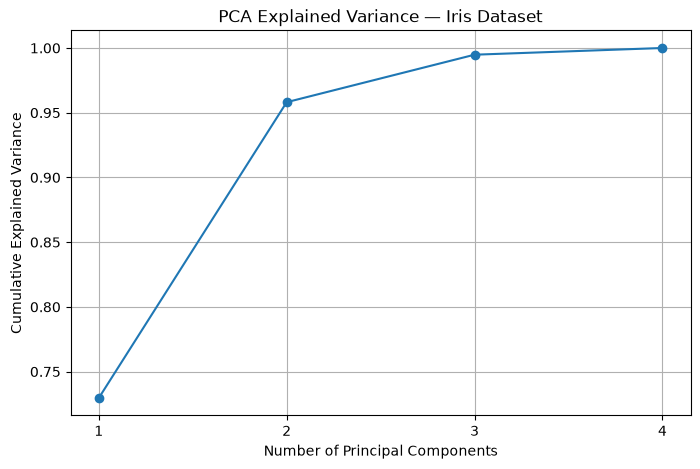

In [8]:
# =========================================================
# TASK 14 — CELL 8
# PCA VISUALIZATION
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance — Iris Dataset")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)

plt.show()

ELBOW ANALYSIS
 k  Inertia
 2 222.3617
 3 139.8205
 4 114.0925
 5  90.9275
 6  81.5444
 7  72.6311
 8  62.5406


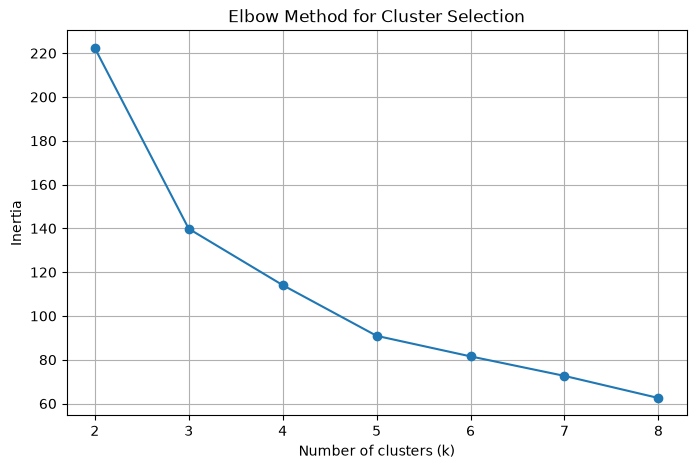

In [9]:
# =========================================================
# TASK 14 — CELL 9
# ELBOW ANALYSIS
# =========================================================

k_values = range(2, 9)

inertias = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias
})

print("=" * 60)
print("ELBOW ANALYSIS")
print("=" * 60)

print(elbow_results.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Cluster Selection")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

SILHOUETTE ANALYSIS
 k  Silhouette Score
 2            0.5818
 3            0.4599
 4            0.3869
 5            0.3459
 6            0.3171
 7            0.3202
 8            0.3387

Best k by silhouette: 2
Best silhouette score: 0.5818


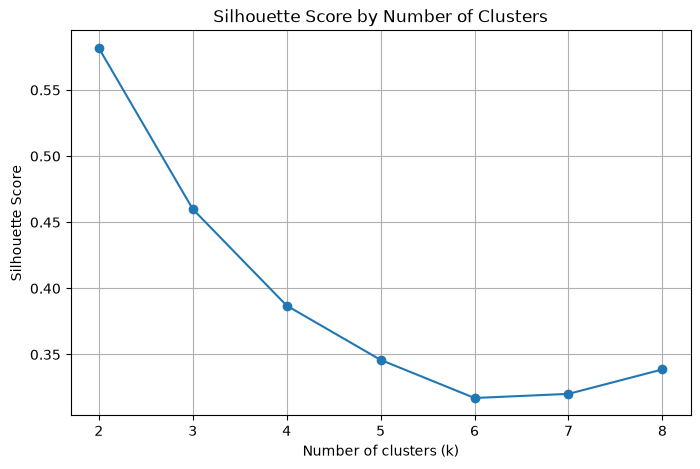

In [10]:
# =========================================================
# TASK 14 — CELL 10
# SILHOUETTE ANALYSIS
# =========================================================

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "k": list(k_values),
    "Silhouette Score": silhouette_scores
})

print("=" * 60)
print("SILHOUETTE ANALYSIS")
print("=" * 60)

print(
    silhouette_results
    .round(4)
    .to_string(index=False)
)

best_k_by_silhouette = int(
    silhouette_results.loc[
        silhouette_results["Silhouette Score"].idxmax(),
        "k"
    ]
)

best_silhouette = float(
    silhouette_results["Silhouette Score"].max()
)

print("\nBest k by silhouette:", best_k_by_silhouette)
print("Best silhouette score:", round(best_silhouette, 4))

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()